pca를 통해 가중치 부여
(피쳐 여러개를 하나로 차원 축소)

피쳐 삭제(실루엣높게나오게한거) -> pca -> kmeans

In [1]:
import mglearn
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_csv('single_variable_data.csv')

In [3]:
health_risk_columns = ['risk_depression', 'risk_drug', 'risk_iadl', 'risk_health', 'risk_age'] #A
infra_gap_columns = ['risk_infra_gap']
#aging_rate삭제 C
economic_instability_columns = ['risk_housing_tenure', 'risk_unemployed', 'risk_subj_econ'] #D
living_conditions_columns = ['risk_housing_safety', 'risk_housing_env'] #E
social_activities_columns = ['risk_group', 'risk_digital'] #F
self_care_deficit_columns = ['risk_nutrition', 'risk_smoke']  #G
despair_columns = ['risk_suicide'] #H

In [4]:
pca_A = PCA(n_components=1)
pca_B = PCA(n_components=1)

pca_D = PCA(n_components=1)
pca_E = PCA(n_components=1)
pca_F = PCA(n_components=1)
pca_G = PCA(n_components=1)
pca_H = PCA(n_components=1)

In [5]:
PC1_health_risk = pca_A.fit_transform(df[health_risk_columns])
PC1_infra_gap = pca_B.fit_transform(df[infra_gap_columns])

PC1_economic_instability = pca_D.fit_transform(df[economic_instability_columns])
PC1_living_conditions = pca_E.fit_transform(df[living_conditions_columns])
PC1_social_activities = pca_F.fit_transform(df[social_activities_columns])
PC1_self_care_deficit = pca_G.fit_transform(df[self_care_deficit_columns])
PC1_despair = pca_H.fit_transform(df[despair_columns])

In [6]:
health_risk = pd.DataFrame(PC1_health_risk, columns = ['health_risk'])
infra_gap = pd.DataFrame(PC1_infra_gap, columns = ['infra_gap'])

economic_instability = pd.DataFrame(PC1_economic_instability, columns = ['economic_instability'])
living_conditions = pd.DataFrame(PC1_living_conditions, columns = ['living_conditions'])
social_activities = pd.DataFrame(PC1_social_activities, columns = ['social_activities'])
self_care_deficit = pd.DataFrame(PC1_self_care_deficit, columns = ['self_care_deficit'])
despair = pd.DataFrame(PC1_despair, columns = ['despair'])

In [7]:
PCA_weighted_df = pd.concat(
    [health_risk, infra_gap, economic_instability, living_conditions, social_activities, self_care_deficit, despair],
    axis=1
)
PCA_weighted_df.head()

,health_risk,infra_gap,economic_instability,living_conditions,social_activities,self_care_deficit,despair
0,-0.284238,0.276049,0.320258,-0.398979,-0.585551,-0.065059,-0.020882
1,0.213517,0.276049,0.518918,0.246012,0.268451,-0.065059,-0.020882
2,-0.043386,0.276049,-0.620617,0.157215,-0.470386,0.934762,-0.020882
3,-0.058352,0.276049,0.320258,-0.048431,0.211728,-0.065059,-0.020882
4,0.657785,0.276049,0.518918,0.187587,0.514730,-0.055607,-0.020882


가중치 부여된 데이터셋으로 kmeans ->

In [8]:
inertia_kmeans = []
sil_scores_kmeans = []
K_range = range(2,14)

for n_clusters in K_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    # n_init: initial centroid 변경횟수 
    # 없이 했다가 추가하니까 실루엣스코어 살짝씩 올랐음
    cluster_labels = kmeans.fit_predict(PCA_weighted_df)
    
    inertia_kmeans.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(PCA_weighted_df, cluster_labels))

In [9]:
inertia_kmeans 

[1668.2152516621209,
 1169.3941959839638,
 868.1918794858668,
 771.3352660733018,
 692.0198371870483,
 643.3603952745867,
 584.2706959019407,
 553.1443131230963,
 516.8685883726097,
 490.7029531157857,
 470.410026259284,
 452.0327058869082]

In [18]:
sil_scores_kmeans

[0.34923056259493623,
 0.3923919258644987,
 0.45807567671165383,
 0.4713521608215436,
 0.4034568567068724,
 0.34931700627806234,
 0.36220445092000264,
 0.3537540608583473,
 0.3223403706017349,
 0.3180784587210932,
 0.3032174446589239,
 0.28442778903011795]

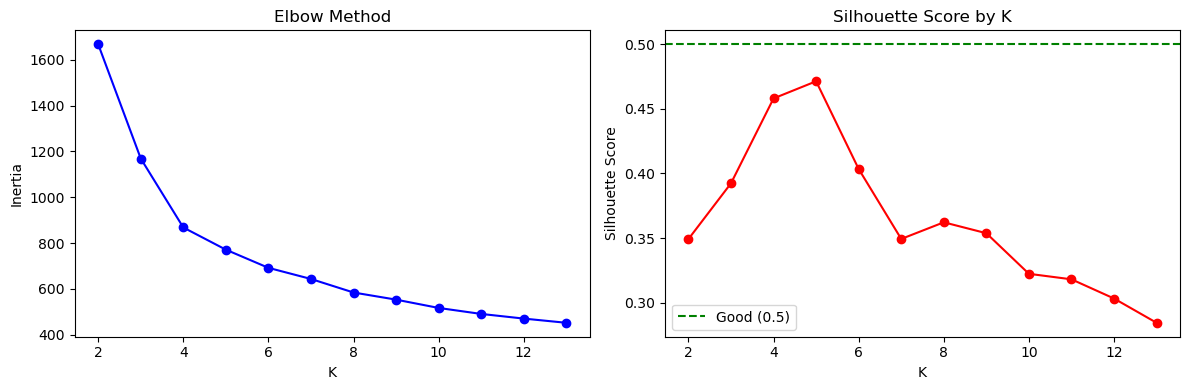

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia_kmeans, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores_kmeans, 'ro-')
axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good (0.5)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].legend()
plt.tight_layout()
plt.show()

부여된 가중치 찾기
가중치 제곱합이 1

In [12]:
weightA = pca_A.components_[0]  # shape: (4,)

weightD = pca_D.components_[0]
weightE = pca_E.components_[0]
weightF = pca_F.components_[0]
weightG = pca_G.components_[0]
weightH = pca_H.components_[0]

print(weightA)
print(weightD)
print(weightE)
print(weightF)
print(weightG)
print(weightH)

[0.62084859 0.29645762 0.19892386 0.61603664 0.32800621]
[0.15547753 0.98405687 0.08636443]
[0.93479486 0.35518808]
[0.17188808 0.98511648]
[0.01890548 0.99982128]
[1.]


k=6에서 그나마 실루엣 스코어가 좋은거 같아서(0.37) 시각화 ->

# 2차원

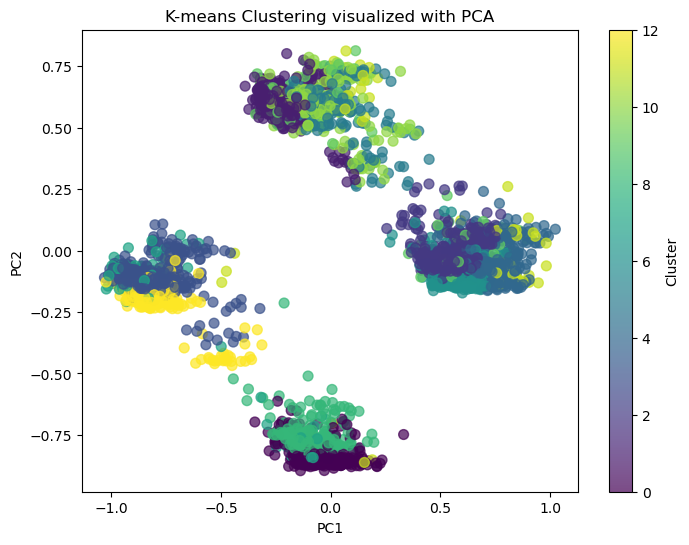

In [20]:
kmeans_k6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels_k6 = kmeans.fit_predict(PCA_weighted_df)

pca_vis_2d = PCA(n_components=2)
X_pca_2d = pca_vis_2d.fit_transform(PCA_weighted_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels_k6, cmap='viridis', s=50, alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

# 3차원

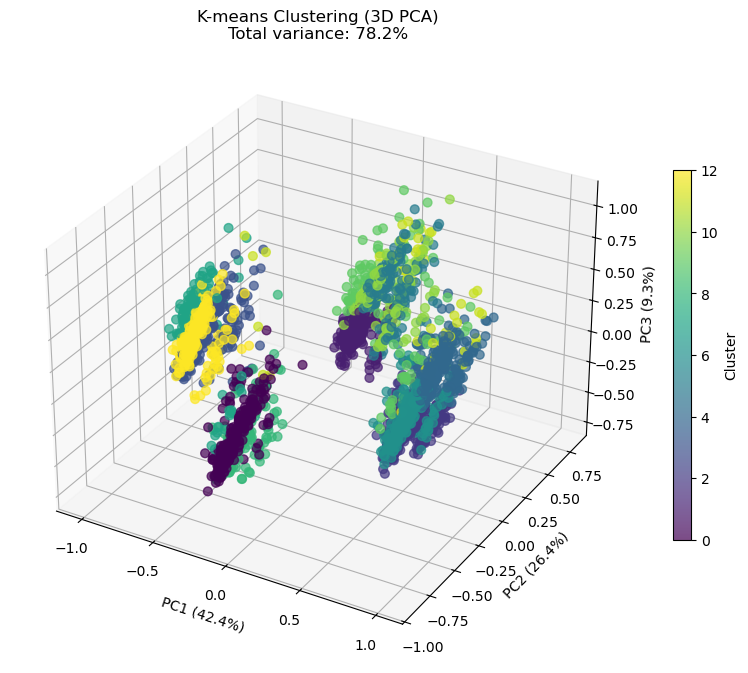

In [21]:
pca_vis_3d = PCA(n_components=3)
X_pca_3d = pca_vis_3d.fit_transform(PCA_weighted_df)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                     c=cluster_labels_k6, cmap='viridis', s=40, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca_vis_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_vis_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_vis_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title(f'K-means Clustering (3D PCA)\nTotal variance: {sum(pca_vis_3d.explained_variance_ratio_):.1%}')

plt.colorbar(scatter, label='Cluster', shrink=0.6)
plt.show()

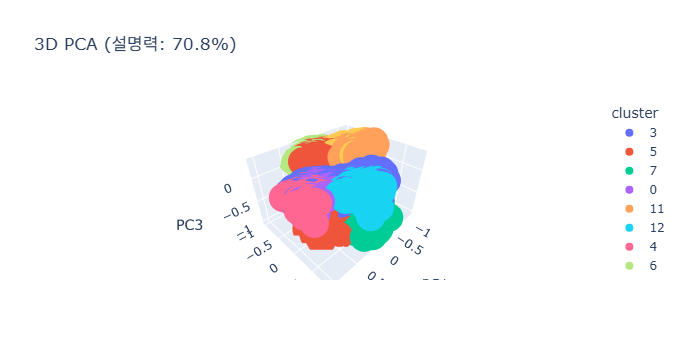

In [15]:
import plotly.express as px
#다른 버전 (ai가 만든거라 저도 뭐가 뭔지 몰라요~)
df_00 = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_00['cluster'] = cluster_labels_k6.astype(str)

fig = px.scatter_3d(df_00, x='PC1', y='PC2', z='PC3', color='cluster',
                    title=f'3D PCA (설명력: {sum(pca_vis_3d.explained_variance_ratio_):.1%})')
fig.show()

In [15]:
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from collections import Counter
from sklearn.cluster import DBSCAN
import numpy as np

In [16]:
hyp = []

for min_samples in range(5, 13):
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(PCA_weighted_df)
    distances, indices = neighbors_fit.kneighbors(PCA_weighted_df)
    sort_distances = np.sort(distances[:, -1])

    # x축 좌표 생성 (0부터 2999까지)
    x_indices = np.arange(len(sort_distances))

    # KneeLocator 설정
    # S: 민감도 (일반적으로 1.0 사용, 값이 작을수록 미세한 변화에 반응)
    # curve: 'convex' (볼록한 곡선 형태)
    # direction: 'increasing' (우상향하는 그래프)
    kneedle = KneeLocator(
    x_indices, 
    sort_distances, 
    S=1.0, 
    curve='convex', 
    direction='increasing'
    )

    # 최적의 꺾임점 정보 추출
    optimal_x = kneedle.knee
    optimal_eps = kneedle.knee_y
    hyp.append({
        'min_sample': min_samples,
        'eps': optimal_eps
    })

    print(f"최적 eps : {optimal_eps:.4f} (인덱스: {optimal_x})")

hyp = pd.DataFrame(hyp)

최적 eps : 0.5078 (인덱스: 3432)
최적 eps : 0.5103 (인덱스: 3422)
최적 eps : 0.4776 (인덱스: 3403)
최적 eps : 0.5077 (인덱스: 3406)
최적 eps : 0.3981 (인덱스: 3319)
최적 eps : 0.4600 (인덱스: 3358)
최적 eps : 0.5368 (인덱스: 3400)
최적 eps : 0.5376 (인덱스: 3388)


In [17]:
for i in range(len(hyp)):
    min_sample = int(hyp.iloc[i]['min_sample'])
    eps = hyp.iloc[i]['eps']
    
    dbscan = DBSCAN(eps=eps, min_samples=min_sample)  
    labels = dbscan.fit_predict(PCA_weighted_df)
    mask = labels != -1
    sil_score = silhouette_score(PCA_weighted_df[mask], labels[mask])
    print(f"\n eps: {eps} min_sample: {min_sample} 실루엣 스코어 : {sil_score:.4f}")


 eps: 0.5077777934846152 min_sample: 5 실루엣 스코어 : 0.3047

 eps: 0.5103105630177162 min_sample: 6 실루엣 스코어 : 0.3042

 eps: 0.4775626961483258 min_sample: 7 실루엣 스코어 : 0.3044

 eps: 0.5077307863783856 min_sample: 8 실루엣 스코어 : 0.3059

 eps: 0.3980637322687231 min_sample: 9 실루엣 스코어 : 0.2886

 eps: 0.4600410789274666 min_sample: 10 실루엣 스코어 : 0.3060

 eps: 0.5368319803705052 min_sample: 11 실루엣 스코어 : 0.3059

 eps: 0.537571083909573 min_sample: 12 실루엣 스코어 : 0.3065
